In [1]:
# CSV 파일에서 와인 데이터 읽어오기
import pandas as pd

wine = pd.read_csv('https://bit.ly/wine_csv_data')

In [2]:
# 처음 5개 행을 확인
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [3]:
# 누락된 값을 확인
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [4]:
# 데이터프레임의 기술 통계량(평균, 표준편차 등)을 확인
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [5]:
# 입력 데이터(alcohol, sugar, pH)와 타겟 데이터(class)를 분리
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [6]:
# 훈련 세트와 테스트 세트로 데이터 분할
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

In [7]:
# 훈련 세트와 테스트 세트의 형태(shape)를 출력
print(train_input.shape, test_input.shape)

(5197, 3) (1300, 3)


In [8]:
# StandardScaler를 사용하여 특성 스케일링 (훈련 세트와 테스트 세트에 적용)
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [9]:
# 로지스틱 회귀 모델을 훈련하고 훈련 및 테스트 세트의 정확도를 출력
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_scaled, train_target)

print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.7808350971714451
0.7776923076923077


In [10]:
# (반복) 로지스틱 회귀 모델을 훈련하고 훈련 및 테스트 세트의 정확도를 출력
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_scaled, train_target)

print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.7808350971714451
0.7776923076923077


In [11]:
# 결정 트리 모델을 훈련하고 훈련 및 테스트 세트의 정확도를 출력
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_scaled, train_target)

print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.996921300750433
0.8592307692307692


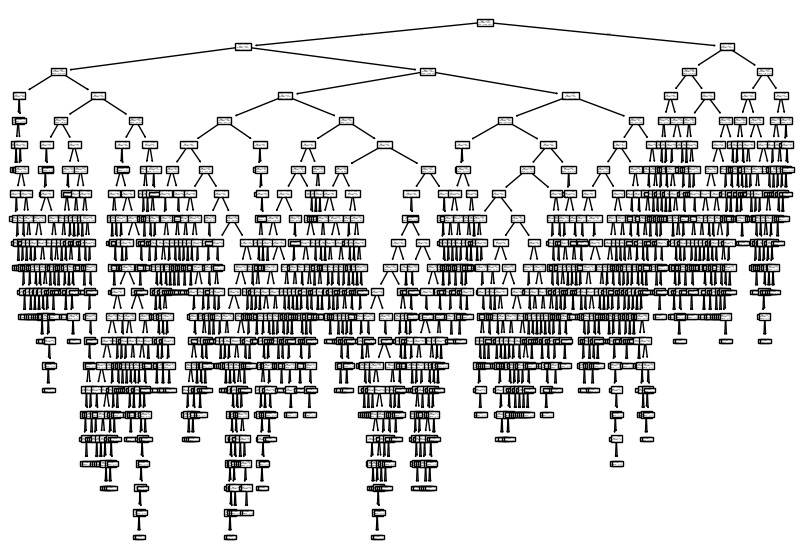

In [12]:
# 훈련된 결정 트리를 시각화 (전체 트리)
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

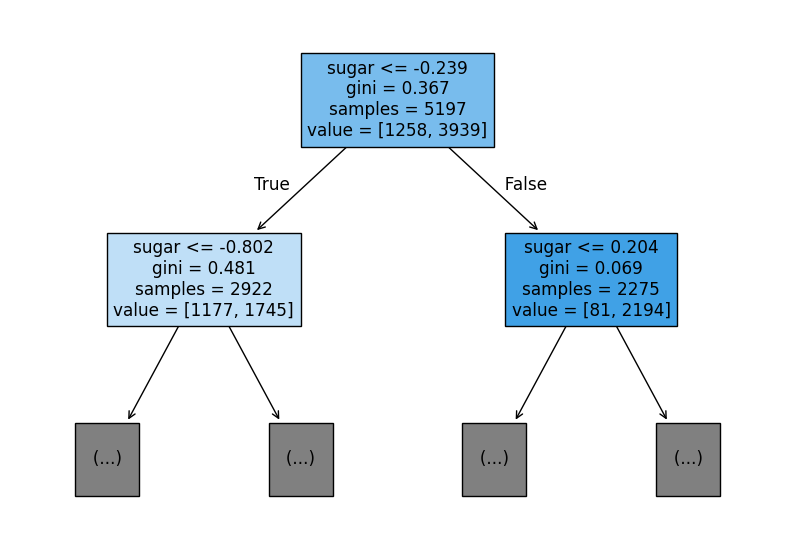

In [13]:
# 훈련된 결정 트리를 시각화 (max_depth=1로 제한, 특성 이름 표시)
plt.figure(figsize=(10,7))
plot_tree(dt, max_depth=1, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [14]:
# max_depth를 3으로 제한한 결정 트리 모델을 훈련하고 정확도를 출력
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)

print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.8454877814123533
0.8415384615384616


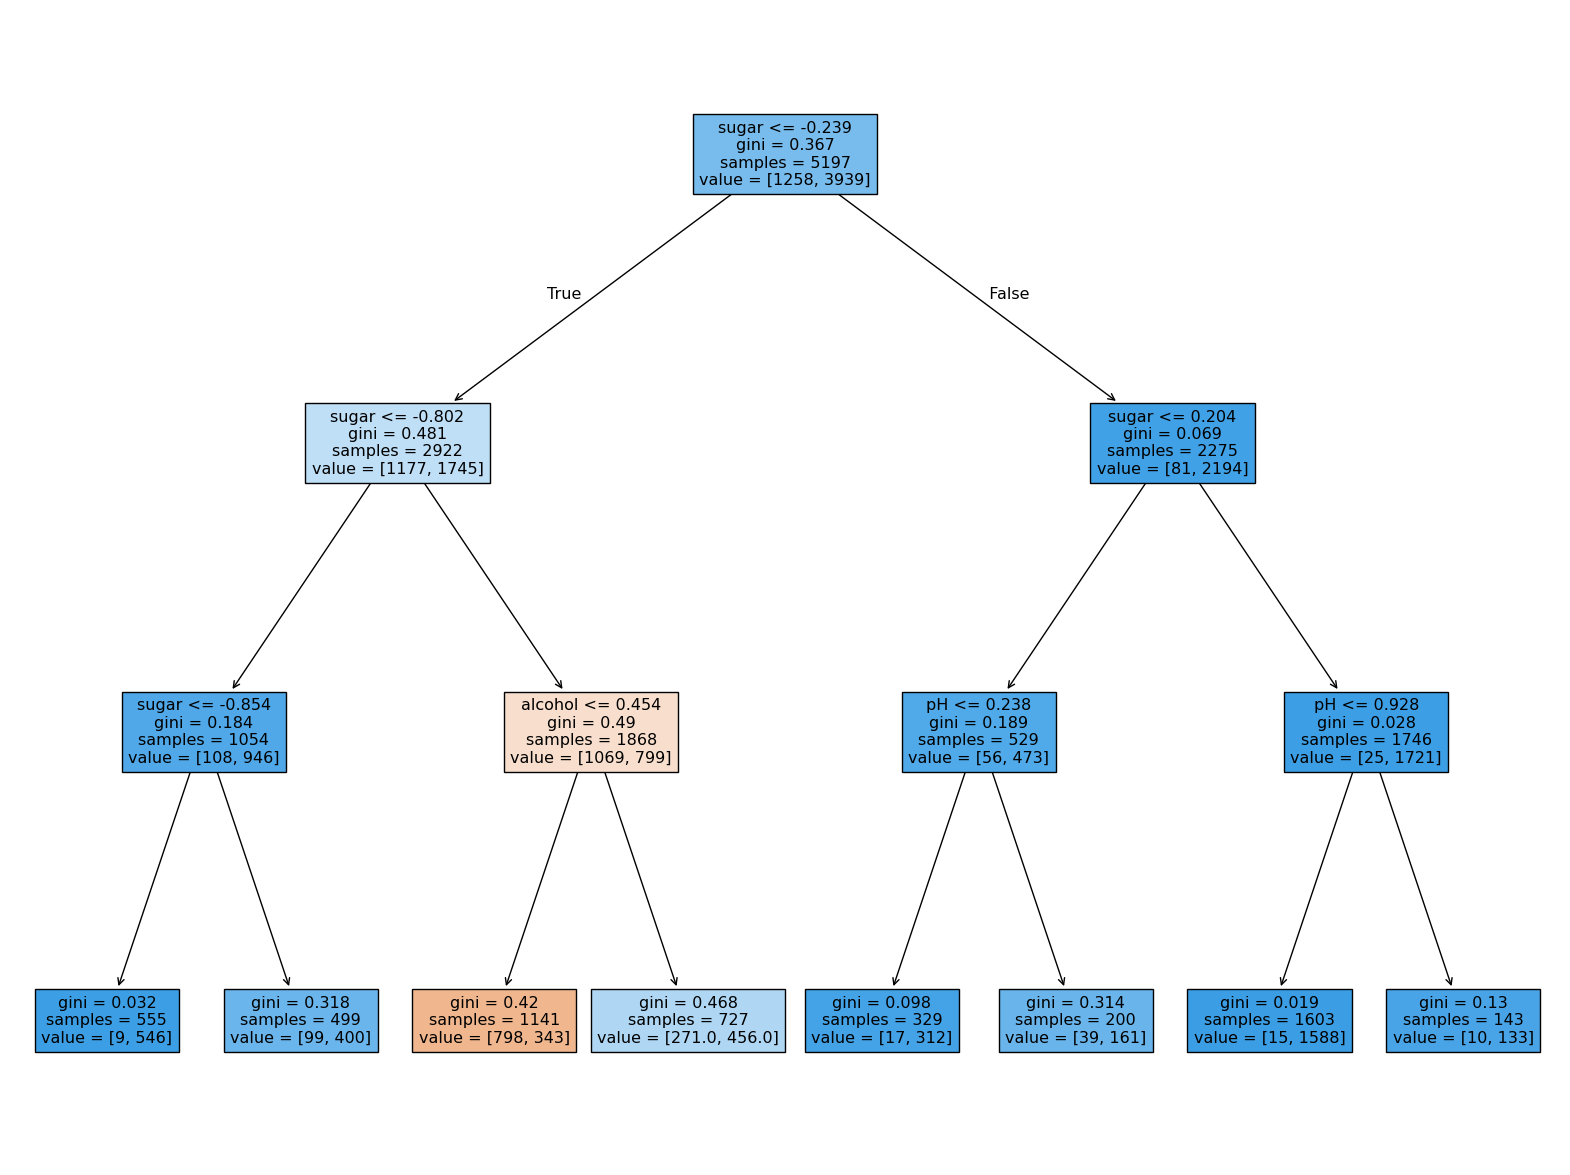

In [15]:
# max_depth=3으로 제한된 훈련된 결정 트리를 시각화
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [16]:
# 검증 세트를 위해 CSV 파일에서 와인 데이터를 다시 읽어오기
import pandas as pd

wine = pd.read_csv('https://bit.ly/wine_csv_data')

In [17]:
# 입력 데이터와 타겟 데이터를 분리
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [18]:
# 훈련 세트와 테스트 세트로 데이터 분할
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

In [19]:
# 훈련 세트를 다시 훈련 세트와 검증 세트로 분할
sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [20]:
# 분할된 훈련 세트(sub_input)와 검증 세트(val_input)의 형태(shape)를 출력
print(sub_input.shape, val_input.shape)

(4157, 3) (1040, 3)


In [21]:
# 검증 세트를 사용하여 결정 트리 모델을 훈련하고 정확도를 출력
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(sub_input, sub_target)

print(dt.score(sub_input, sub_target))
print(dt.score(val_input, val_target))

0.9971133028626413
0.864423076923077


In [22]:
# 교차 검증을 수행하고 결과를 출력
from sklearn.model_selection import cross_validate

scores = cross_validate(dt, train_input, train_target)
print(scores)

{'fit_time': array([0.00942636, 0.00843835, 0.0090158 , 0.00852823, 0.00818563]), 'score_time': array([0.00130081, 0.00169992, 0.00115013, 0.00120854, 0.00120068]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}


In [23]:
# 교차 검증 점수의 평균을 계산하고 출력
import numpy as np

print(np.mean(scores['test_score']))

0.855300214703487


In [24]:
# 랜덤 포레스트 모델을 훈련하고 훈련, OOB, 테스트 세트의 정확도를 출력
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 데이터 불러오기
wine = pd.read_csv('https://bit.ly/wine_csv_data')

# 입력 데이터와 정답 데이터 분리
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

# 훈련 세트와 테스트 세트 분리
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42
)

# OOB score를 사용하는 랜덤포레스트 모델 생성
rf = RandomForestClassifier(
    oob_score=True,
    max_depth=5,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

# 모델 학습
rf.fit(train_input, train_target)

print("Train score:", rf.score(train_input, train_target))
print("OOB score:", rf.oob_score_)
print("Test score:", rf.score(test_input, test_target))

Train score: 0.8685780257841063
OOB score: 0.8579949971137194
Test score: 0.8515384615384616


In [25]:
# 과제 1

In [26]:
# 와인 데이터셋을 불러온 뒤, 입력 데이터와 정답 데이터를 분리하기
import pandas as pd

wine = pd.read_csv('https://bit.ly/wine_csv_data')
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [27]:
# 전체 데이터를 Train set과 Test set으로 나누기
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

In [28]:
# Train set을 다시 Train set과 Validation set으로 나누기
sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [29]:
# max_depths = [1, 3, 5, 10]으로 설정하기
max_depths = [1, 3, 5, 10]

In [30]:
# 반복문을 사용하여 max_depth 값을 하나씩 바꿔가며
#    DecisionTreeClassifier 모델을 학습시키기
from sklearn.tree import DecisionTreeClassifier

results = []
for depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(sub_input, sub_target)

    train_score = dt.score(sub_input, sub_target)
    val_score = dt.score(val_input, val_target)
    test_score = dt.score(test_input, test_target) # Use the original test_input and test_target
    results.append({'max_depth': depth, 'train_score': train_score, 'val_score': val_score, 'test_score': test_score})

In [31]:
# 각 max_depth 값에 대해 train score, validation score, test score를 출력
print("Decision Tree Model Scores:")
for res in results:
    print(f"Max Depth: {res['max_depth']}")
    print(f"  Train Score: {res['train_score']:.4f}")
    print(f"  Validation Score: {res['val_score']:.4f}")
    print(f"  Test Score: {res['test_score']:.4f}")

Decision Tree Model Scores:
Max Depth: 1
  Train Score: 0.7623
  Validation Score: 0.7404
  Test Score: 0.7377
Max Depth: 3
  Train Score: 0.8482
  Validation Score: 0.8490
  Test Score: 0.8415
Max Depth: 5
  Train Score: 0.8703
  Validation Score: 0.8712
  Test Score: 0.8600
Max Depth: 10
  Train Score: 0.9350
  Validation Score: 0.8529
  Test Score: 0.8500


In [32]:
# 출력된 결과를 보고 어떤 max_depth 값이 가장 적절한지 확인

# 결과를 보면 max_depth가 1일 때는 훈련 세트와 검증 세트 모두 점수가 낮아 과소적합의 경향을 보인다. max_depth가 3, 5, 10으로 증가할수록 훈련 세트 점수는 계속 높아지지만, 검증 세트 점수는 일정 수준 이상에서는 크게 향상되지 않거나 오히려 감소하는 경향을 보인다.

# 이러한 결과를 바탕으로 max_depth가 5인 경우가 모델의 일반화 성능이 가장 좋다고 판단할 수 있다.

In [33]:
# 과제 2

In [34]:
# 와인 데이터셋을 불러온 뒤, 입력 데이터와 정답 데이터를 분리하기
import pandas as pd

wine = pd.read_csv('https://bit.ly/wine_csv_data')
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [35]:
# 전체 데이터를 Train set과 Test set로 나누기
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

In [36]:
# DecisionTreeClassifier 모델을 생성하기
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

In [37]:
# K값(3, 5, 10)에 대해 교차검증을 수행
from sklearn.model_selection import cross_validate
import numpy as np

k_values = [3, 5, 10]
cv_results = []

for k in k_values:
    scores = cross_validate(dt_model, train_input, train_target, cv=k)
    cv_results.append({'k': k, 'scores': scores})

In [38]:
# 각 K값에 대해 각 Fold에서 나온 검증 점수, Fold 점수들의 평균값 출력하기
print("Cross-validation Results:")
for res in cv_results:
    k = res['k']
    scores = res['scores']
    print(f"\nK = {k}:")
    print(f"  Individual Fold Test Scores: {scores['test_score']}")
    print(f"  Average Test Score: {np.mean(scores['test_score']):.4f}")

Cross-validation Results:

K = 3:
  Individual Fold Test Scores: [0.84535488 0.87182448 0.84757506]
  Average Test Score: 0.8549

K = 5:
  Individual Fold Test Scores: [0.86923077 0.84615385 0.87680462 0.84889317 0.83541867]
  Average Test Score: 0.8553

K = 10:
  Individual Fold Test Scores: [0.84807692 0.85769231 0.875      0.86730769 0.88461538 0.87692308
 0.875      0.86705202 0.8477842  0.81695568]
  Average Test Score: 0.8616


In [40]:
# K값에 따라 평균 score가 어떻게 달라지는지 확인하기

# 평균 test_score는 K=3일 때 약 0.8552, K=5일 때 약 0.8553, K=10일 때 약 0.8569로 나타난다.

# 이 결과는 폴드의 수가 증가할수록 모델의 일반화 성능을 보다 안정적으로 측정할 수 있음을 시사한다.